In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [1]:
from pathlib import Path
data_path = Path("../data/raw")
files = list(data_path.glob("*.csv"))
files

[WindowsPath('../data/raw/1.csv'),
 WindowsPath('../data/raw/10.csv'),
 WindowsPath('../data/raw/11.csv'),
 WindowsPath('../data/raw/12.csv'),
 WindowsPath('../data/raw/13.csv'),
 WindowsPath('../data/raw/14.csv'),
 WindowsPath('../data/raw/15.csv'),
 WindowsPath('../data/raw/16.csv'),
 WindowsPath('../data/raw/17.csv'),
 WindowsPath('../data/raw/18.csv'),
 WindowsPath('../data/raw/19.csv'),
 WindowsPath('../data/raw/2.csv'),
 WindowsPath('../data/raw/20.csv'),
 WindowsPath('../data/raw/21.csv'),
 WindowsPath('../data/raw/22.csv'),
 WindowsPath('../data/raw/23.csv'),
 WindowsPath('../data/raw/24.csv'),
 WindowsPath('../data/raw/25.csv'),
 WindowsPath('../data/raw/26.csv'),
 WindowsPath('../data/raw/27.csv'),
 WindowsPath('../data/raw/28.csv'),
 WindowsPath('../data/raw/29.csv'),
 WindowsPath('../data/raw/3.csv'),
 WindowsPath('../data/raw/30.csv'),
 WindowsPath('../data/raw/31.csv'),
 WindowsPath('../data/raw/32.csv'),
 WindowsPath('../data/raw/33.csv'),
 WindowsPath('../data/raw/34.cs

In [2]:
len(files)

39

In [5]:
file_path = files[0]
df = pd.read_csv(file_path)


In [6]:
df.head()

,TS,V1,V2,V3,W1,W2,W3
0,1481729400,237.892787,241.452465,239.091898,0.0,0.0,0.0
1,1481733000,239.871393,243.446685,241.501854,0.0,0.0,0.0
2,1481736600,236.130379,239.350839,237.127877,0.0,0.0,0.0
3,1481740200,237.544574,240.841078,238.190673,0.0,0.0,0.0
4,1481743800,238.920708,242.163186,238.454141,0.0,0.0,0.0


In [8]:
df.shape


(7508, 7)

In [9]:
df.columns

Index(['TS', 'V1', 'V2', 'V3', 'W1', 'W2', 'W3'], dtype='str')

In [10]:
list(df.columns)

['TS', 'V1', 'V2', 'V3', 'W1', 'W2', 'W3']

In [11]:
df.dtypes


TS      int64
V1    float64
V2    float64
V3    float64
W1    float64
W2    float64
W3    float64
dtype: object

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7508 entries, 0 to 7507
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype        
---  ------    --------------  -----        
 0   TS        7508 non-null   int64        
 1   V1        7508 non-null   float64      
 2   V2        7508 non-null   float64      
 3   V3        7508 non-null   float64      
 4   W1        7508 non-null   float64      
 5   W2        7508 non-null   float64      
 6   W3        7508 non-null   float64      
 7   datetime  7508 non-null   datetime64[s]
dtypes: datetime64[s](1), float64(6), int64(1)
memory usage: 469.4 KB


In [13]:
df.describe()

,TS,V1,V2,V3,W1,W2,W3
count,7.508000e+03,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000,7508.000000
mean,1.500014e+09,234.893460,237.003085,236.197476,116.233894,59.676556,94.663193
std,1.013052e+07,4.006955,4.170364,3.840411,179.049981,94.125354,142.109091
min,1.481729e+09,214.105829,215.297552,215.190582,0.000000,0.000000,0.000000
25%,1.492986e+09,231.794190,233.724660,233.118105,0.000000,0.000000,0.000000
50%,1.499789e+09,234.961608,236.950159,236.160989,89.335588,24.615993,48.548962
75%,1.507888e+09,238.202875,240.377119,239.521487,151.861400,89.613924,152.356646
max,1.528135e+09,248.105153,251.596138,248.651842,5315.689031,1723.826154,1453.336588


In [14]:
df.isna().sum()

TS    0
V1    0
V2    0
V3    0
W1    0
W2    0
W3    0
dtype: int64

In [15]:
df.isna().mean()*100

TS    0.0
V1    0.0
V2    0.0
V3    0.0
W1    0.0
W2    0.0
W3    0.0
dtype: float64

In [16]:
df["TS"].head()

0    1481729400
1    1481733000
2    1481736600
3    1481740200
4    1481743800
Name: TS, dtype: int64

In [17]:
df["datetime"] = pd.to_datetime(
    df["TS"],
    unit="s"
)

In [18]:
df[["TS","datetime"]].head()

,TS,datetime
0,1481729400,2016-12-14 15:30:00
1,1481733000,2016-12-14 16:30:00
2,1481736600,2016-12-14 17:30:00
3,1481740200,2016-12-14 18:30:00
4,1481743800,2016-12-14 19:30:00


In [19]:
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())

Start: 2016-12-14 15:30:00
End: 2018-06-04 18:00:00


In [20]:
df["datetime"].diff().value_counts().head(10)

datetime
0 days 01:00:00    7435
0 days 04:00:00      10
0 days 03:00:00       8
0 days 02:00:00       7
0 days 05:00:00       5
0 days 18:00:00       4
0 days 09:00:00       3
0 days 07:00:00       3
0 days 12:00:00       2
0 days 16:00:00       2
Name: count, dtype: int64

In [21]:
df["datetime"].duplicated().sum()

np.int64(0)

In [22]:
df.head()

,TS,V1,V2,V3,W1,W2,W3,datetime
0,1481729400,237.892787,241.452465,239.091898,0.0,0.0,0.0,2016-12-14 15:30:00
1,1481733000,239.871393,243.446685,241.501854,0.0,0.0,0.0,2016-12-14 16:30:00
2,1481736600,236.130379,239.350839,237.127877,0.0,0.0,0.0,2016-12-14 17:30:00
3,1481740200,237.544574,240.841078,238.190673,0.0,0.0,0.0,2016-12-14 18:30:00
4,1481743800,238.920708,242.163186,238.454141,0.0,0.0,0.0,2016-12-14 19:30:00


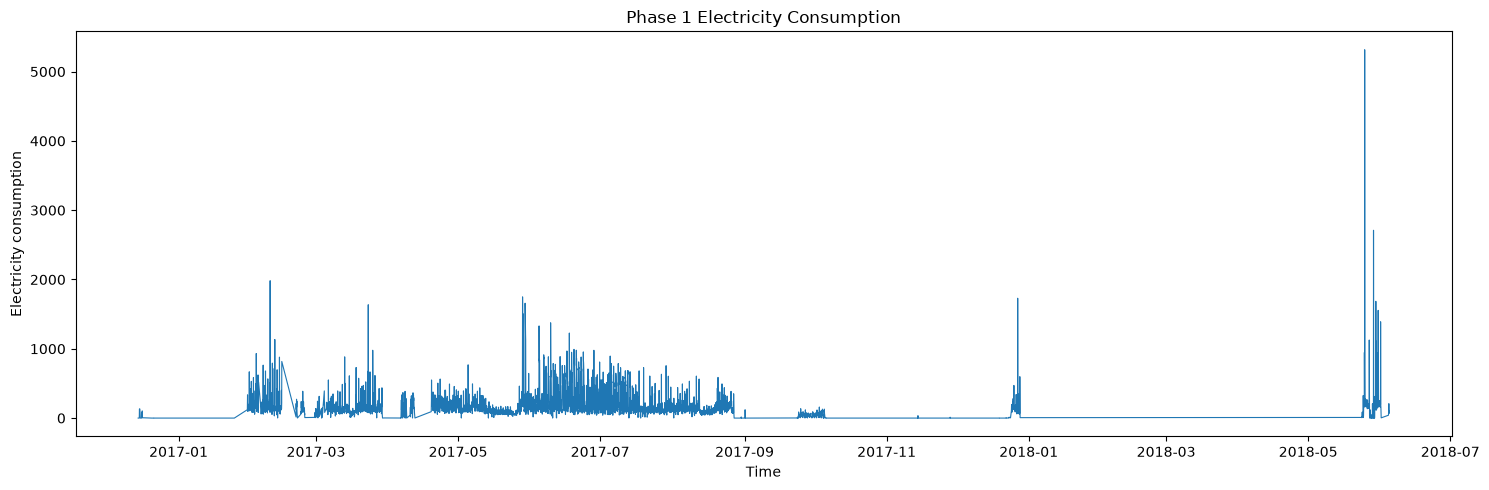

In [23]:
plt.figure(figsize=(15, 5))
plt.plot(
    df["datetime"],
    df["W1"],
    linewidth=0.8
)
plt.xlabel("Time")
plt.ylabel("Electricity consumption")
plt.title("Phase 1 Electricity Consumption")
plt.tight_layout()
plt.show()

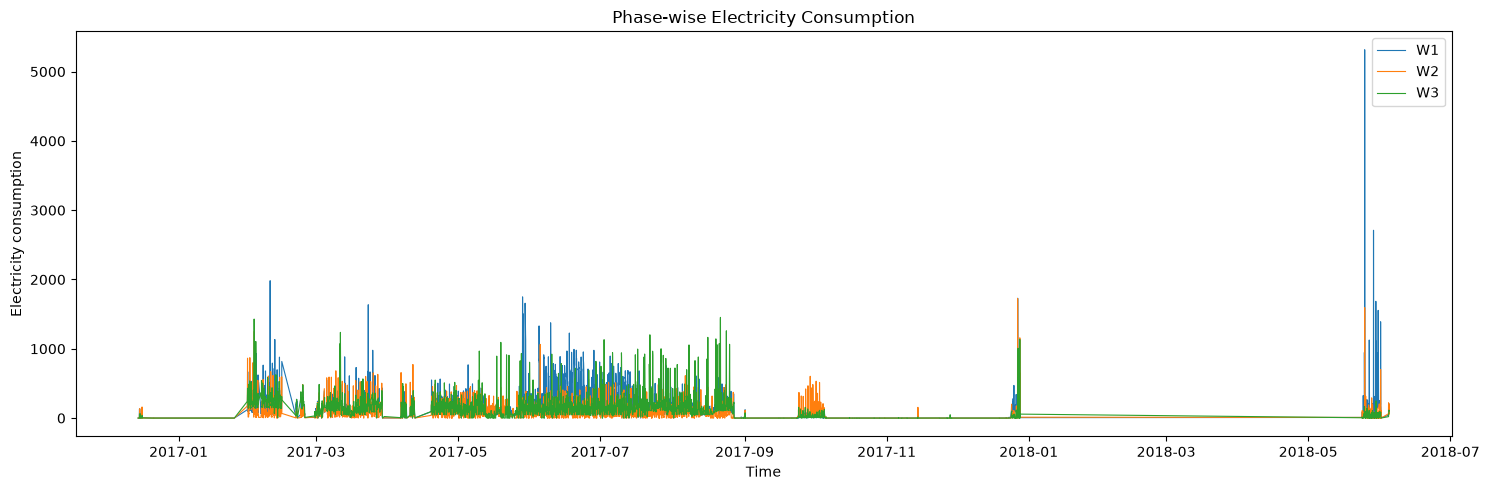

In [24]:
plt.figure(figsize=(15, 5))

for column in ["W1", "W2", "W3"]:
    plt.plot(
        df["datetime"],
        df[column],
        label=column,
        linewidth=0.8
    )
plt.xlabel("Time")
plt.ylabel("Electricity consumption")
plt.title("Phase-wise Electricity Consumption")
plt.legend()
plt.tight_layout()
plt.show()

## Initial Observations

Questions to investigate:

1. What is the sampling interval?
2. Are timestamps continuous?
3. How many missing values are present?
4. What is the typical electricity consumption?
5. Are there unusual spikes?
6. Do the three phases behave similarly?
7. Does electricity consumption vary by time of day?
8. Are there obvious daily or weekly patterns?

## 2. Data Quality Analysis

### 2.1 Time Interval Analysis

In [26]:
time_diff = df["datetime"].diff().dropna()
print("Most common time intervals:")
print(time_diff.value_counts().head(10))

Most common time intervals:
datetime
0 days 01:00:00    7435
0 days 04:00:00      10
0 days 03:00:00       8
0 days 02:00:00       7
0 days 05:00:00       5
0 days 18:00:00       4
0 days 09:00:00       3
0 days 07:00:00       3
0 days 12:00:00       2
0 days 16:00:00       2
Name: count, dtype: int64


In [27]:
print("Expected interval:", pd.Timedelta(hours=1))
print("Number of non-1-hour intervals:",
     (time_diff != pd.Timedelta(hours=1)).sum())

Expected interval: 0 days 01:00:00
Number of non-1-hour intervals: 72


In [28]:
expected_hours = (
    (df["datetime"].max() - df["datetime"].min()) / pd.Timedelta(hours=1)
)
actual_rows = len(df)
print("Expected hourly intervals:", int(expected_hours) + 1)
print("Actual observations:", actual_rows)
print("Approximate missing timestamps:",
      int(expected_hours) + 1 - actual_rows)

Expected hourly intervals: 12891
Actual observations: 7508
Approximate missing timestamps: 5383


### 2.2 Consumption Distributions

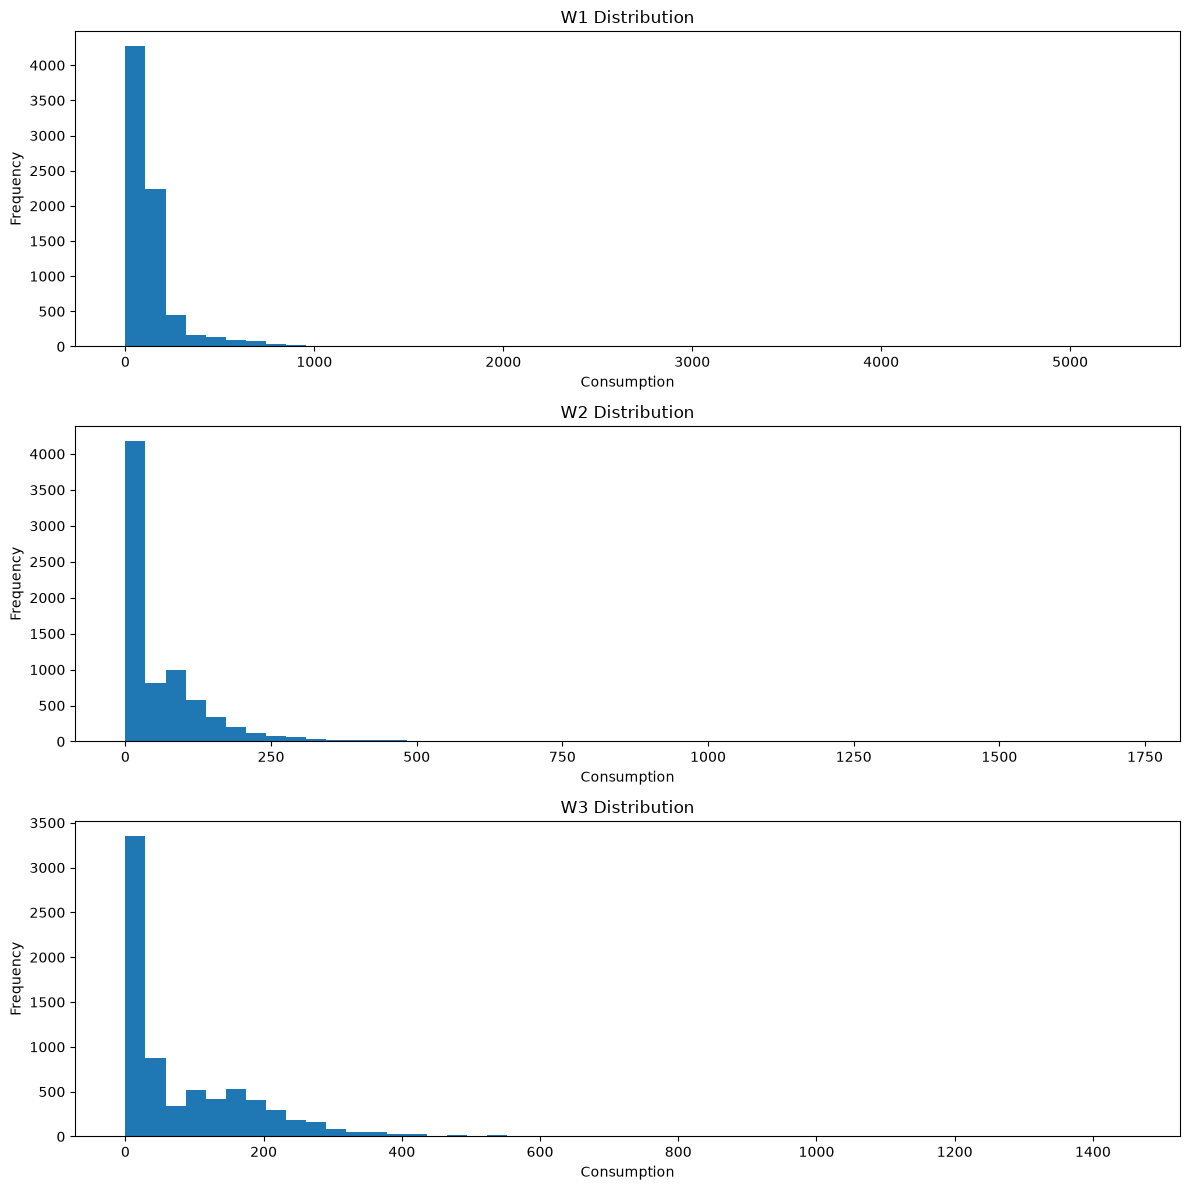

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
for ax, column in zip(axes, ["W1", "W2", "W3"]):
    ax.hist(df[column], bins=50)
    ax.set_title(f"{column} Distribution")
    ax.set_xlabel("Consumption")
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

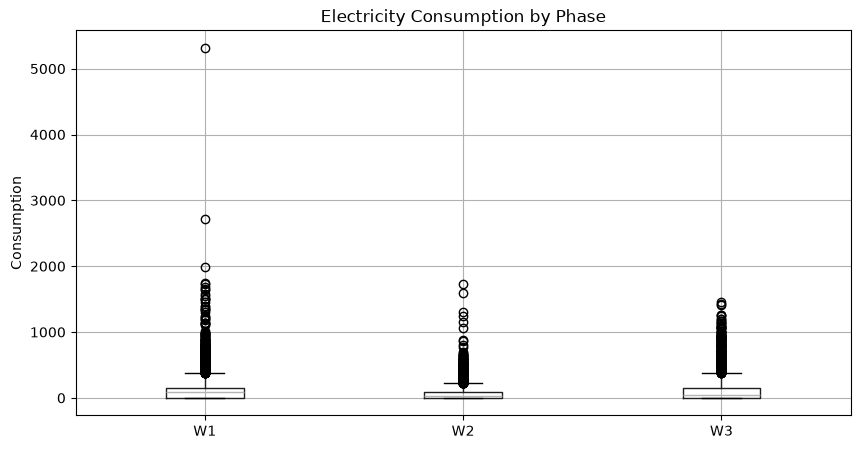

In [30]:
plt.figure(figsize=(10, 5))
df[["W1", "W2", "W3"]].boxplot()
plt.title("Electricity Consumption by Phase")
plt.ylabel("Consumption")
plt.show()

### 2.3 Hourly Consumption Pattern

In [31]:
df["hour"] = df["datetime"].dt.hour

In [32]:
df["hour"].unique()

array([15, 16, 17, 18, 19, 20, 21, 22, 23,  0,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12, 13, 14], dtype=int32)

In [33]:
hourly_pattern = df.groupby("hour")["W1"].mean()
hourly_pattern

hour
0     131.539746
1     128.601969
2      86.382917
3      88.953258
4      90.606363
5      98.181811
6     116.736137
7     188.529386
8      94.949759
9      78.899998
10     83.535787
11     79.983045
12     74.684853
13     87.040773
14    104.261501
15    117.285472
16     91.367218
17    149.548792
18    167.736650
19    153.593451
20    151.898846
21    146.721747
22    140.779146
23    135.936256
Name: W1, dtype: float64

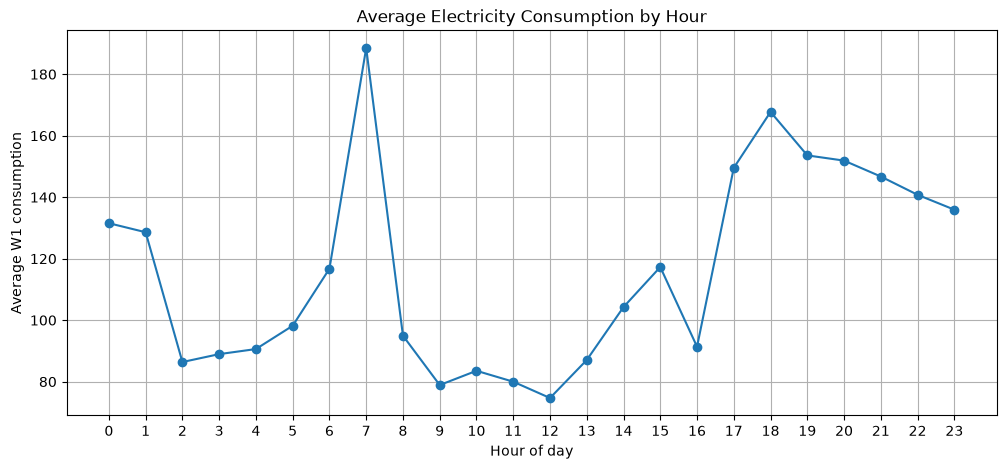

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker="o")
plt.xlabel("Hour of day")
plt.ylabel("Average W1 consumption")
plt.title("Average Electricity Consumption by Hour")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [35]:
df["day_of_week"] = df["datetime"].dt.dayofweek

In [36]:
weekly_pattern = df.groupby("day_of_week")["W1"].mean()
weekly_pattern

day_of_week
0    114.235429
1    119.009631
2    122.150003
3    114.770975
4    116.839993
5    102.183678
6    125.033557
Name: W1, dtype: float64

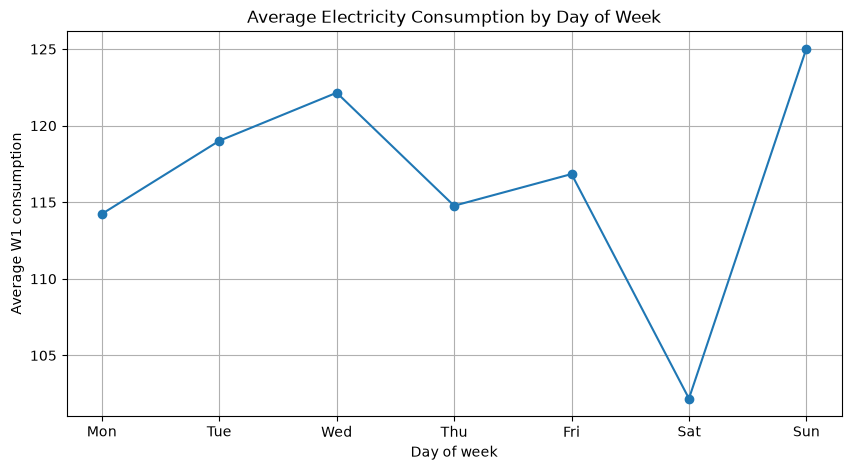

In [37]:
plt.figure(figsize=(10, 5))
plt.plot(
    weekly_pattern.index,
    weekly_pattern.values,
    marker="o"
)
plt.xlabel("Day of week")
plt.ylabel("Average W1 consumption")
plt.title("Average Electricity Consumption by Day of Week")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
)
plt.grid(True)
plt.show()

In [38]:
df["is_weekend"] = df["day_of_week"] >= 5

In [39]:
df["is_weekend"].value_counts()

is_weekend
False    5373
True     2135
Name: count, dtype: int64

In [40]:
df.groupby("is_weekend")["W1"].mean()

is_weekend
False    117.338731
True     113.453431
Name: W1, dtype: float64

## Initial EDA Findings

### Data quality
- The dataset contains 7,508 observations for apartment 1.
- No null values were found in the measured columns.
- No duplicate timestamps were found.
- Most observations are separated by one hour, although 72 intervals differ from the expected one-hour interval.
- Long gaps exist in the observation period, so these should be treated as periods without observations rather than automatically labeling them as missing values.

### Consumption
- W1, W2 and W3 have right-skewed distributions with occasional high-consumption events.
- W1 has a substantially higher mean than median, indicating the influence of high-consumption observations.
- High values will not be removed without further investigation.

### Temporal patterns
- W1 consumption varies by hour of day.
- The apartment shows differences in average W1 consumption across days of the week.
- Weekday and weekend averages are relatively close for this apartment, so the usefulness of `is_weekend` should be evaluated across more households.

### Next step
The next stage is to determine how W1, W2 and W3 should be represented in the prediction target and to investigate the consistency of these patterns across apartments.